## Importar Bibliotecas

In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU disponível: []


## Caminhos e Configurações

In [3]:
# Para rodar no Colab, comente o base_path local e descomente as linhas do Drive
# from google.colab import drive
# drive.mount('/content/drive')
# base_path = 'caminho_datasets'

base_path   = r'datasets'
TARGET_SIZE = (224, 224)

print("Base path:", base_path)
print("Pastas encontradas:")
for p in os.listdir(base_path):
    print(f"  {repr(p)}")

Base path: datasets
Pastas encontradas:
  'chest_xray'


## Carregar Metadados

In [4]:
CLASSES = {'NORMAL', 'PNEUMONIA'}

def normalizar_classe(nome_dir):
    u = nome_dir.upper()
    if 'PNEUMONIA' in u: return 'PNEUMONIA'
    if 'NORMAL'    in u: return 'NORMAL'
    return None  # ignora pastas desconhecidas


dados = []
subdirs = {'chest_xray': 'chest_xray', 'ChestX-ray8': 'ChestX-ray8', 'COVID-19 Image Data Collection': 'COVID-19 Image Data Collection'}

for dataset in os.listdir(base_path):
    print(f'DATASET: {dataset}')
    dataset_path = os.path.join(base_path, os.path.join(dataset, subdirs[dataset]))


    if not os.path.isdir(dataset_path):
        continue

    for classe_dir in os.listdir(dataset_path):
        classe_path = os.path.join(dataset_path, classe_dir)
        if not os.path.isdir(classe_path):
            continue

        classe = normalizar_classe(classe_dir)
        if classe is None:
            continue

        for img_nome in os.listdir(classe_path):
            if not img_nome.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            caminho = os.path.join(classe_path, img_nome)
            img     = cv2.imread(caminho)

            if img is None:
                altura, largura, canais = None, None, None
            else:
                altura, largura = img.shape[:2]
                canais          = img.shape[2] if len(img.shape) == 3 else 1

            dados.append({
                'dataset' : dataset,
                'classe'  : classe,
                'imagem'  : img_nome,
                'caminho' : caminho,
                'altura'  : altura,
                'largura' : largura,
                'canais'  : canais
            })

df = pd.DataFrame(dados)
print(f"\nTotal de registros carregados: {len(df)}")
print("\nContagem por dataset e classe:")
print(df.groupby(['dataset', 'classe']).size().reset_index(name='quantidade').to_string(index=False))

DATASET: chest_xray

Total de registros carregados: 30

Contagem por dataset e classe:
   dataset    classe  quantidade
chest_xray    NORMAL          15
chest_xray PNEUMONIA          15


## Visão Geral

In [5]:
total_por_dataset = df.groupby('dataset').size().reset_index(name='total')
contagem_geral    = df['classe'].value_counts().reset_index()
contagem_geral.columns = ['classe', 'quantidade']

print("=" * 55)
print(f"{'VISÃO GERAL DOS DATASETS':^55}")
print("=" * 55)
print("\n- Total por dataset:")
print(total_por_dataset.to_string(index=False))
print("\n- Total geral por classe (conjunto unificado):")
print(contagem_geral.to_string(index=False))
print(f"\n- Total de imagens    : {len(df)}")
print(f"- Imagens corrompidas : {df['altura'].isna().sum()}")

               VISÃO GERAL DOS DATASETS                

- Total por dataset:
   dataset  total
chest_xray     30

- Total geral por classe (conjunto unificado):
   classe  quantidade
   NORMAL          15
PNEUMONIA          15

- Total de imagens    : 30
- Imagens corrompidas : 0


## Distribuição de Classes

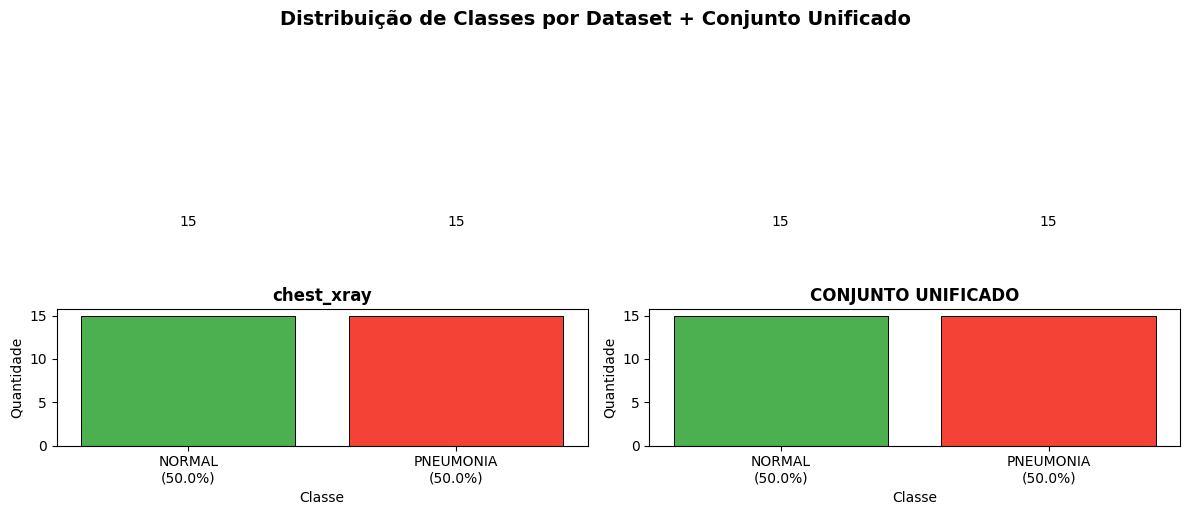

In [6]:
datasets = df['dataset'].unique()
n        = len(datasets)
cores    = {'NORMAL': '#4CAF50', 'PNEUMONIA': '#F44336'}

fig, axes = plt.subplots(1, n + 1, figsize=(6 * (n + 1), 5))

# Um gráfico por dataset
for ax, ds in zip(axes[:n], datasets):
    df_temp  = df[df['dataset'] == ds]
    contagem = df_temp['classe'].value_counts()
    bars     = ax.bar(contagem.index, contagem.values,
                      color=[cores[c] for c in contagem.index],
                      edgecolor='black', linewidth=0.7)
    ax.set_title(ds, fontsize=12, fontweight='bold')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Quantidade')
    total = contagem.sum()
    pct   = (contagem / total * 100).round(1)
    for bar, val in zip(bars, contagem.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                str(val), ha='center', va='bottom', fontsize=10)
    ax.set_xticks(range(len(contagem)))
    ax.set_xticklabels([f'{c}\n({pct[c]}%)' for c in contagem.index])

# Gráfico do conjunto unificado
ax_total   = axes[n]
contagem_u = df['classe'].value_counts()
bars = ax_total.bar(contagem_u.index, contagem_u.values,
                    color=[cores[c] for c in contagem_u.index],
                    edgecolor='black', linewidth=0.7)
ax_total.set_title('CONJUNTO UNIFICADO', fontsize=12, fontweight='bold')
ax_total.set_xlabel('Classe')
ax_total.set_ylabel('Quantidade')
total_u = contagem_u.sum()
pct_u   = (contagem_u / total_u * 100).round(1)
for bar, val in zip(bars, contagem_u.values):
    ax_total.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                  str(val), ha='center', va='bottom', fontsize=10)
ax_total.set_xticks(range(len(contagem_u)))
ax_total.set_xticklabels([f'{c}\n({pct_u[c]}%)' for c in contagem_u.index])

plt.suptitle('Distribuição de Classes por Dataset + Conjunto Unificado',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('graphs', exist_ok=True)
plt.savefig('graphs/distribuicao_classes.png', dpi=150, bbox_inches='tight')

## Distribuição de Dimensões


 chest_xray
   Altura  — min: 439 | max: 2155 | média: 1234.9 | mediana: 1291
   Largura — min: 712 | max: 2498 | média: 1590.7 | mediana: 1700


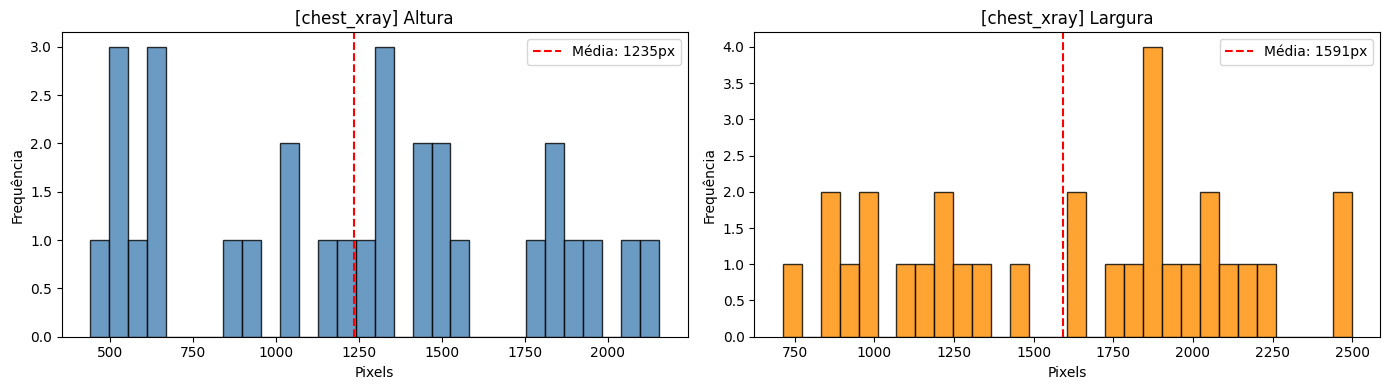

In [7]:
fig, axes = plt.subplots(len(datasets), 2, figsize=(14, 4 * len(datasets)))

for i, ds in enumerate(datasets):
    df_temp = df[df['dataset'] == ds].dropna(subset=['altura', 'largura'])
    ax_h    = axes[i][0] if len(datasets) > 1 else axes[0]
    ax_w    = axes[i][1] if len(datasets) > 1 else axes[1]

    ax_h.hist(df_temp['altura'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    ax_h.set_title(f'[{ds}] Altura')
    ax_h.set_xlabel('Pixels')
    ax_h.set_ylabel('Frequência')
    ax_h.axvline(df_temp['altura'].mean(), color='red', linestyle='--',
                 label=f"Média: {df_temp['altura'].mean():.0f}px")
    ax_h.legend()

    ax_w.hist(df_temp['largura'], bins=30, color='darkorange', edgecolor='black', alpha=0.8)
    ax_w.set_title(f'[{ds}] Largura')
    ax_w.set_xlabel('Pixels')
    ax_w.set_ylabel('Frequência')
    ax_w.axvline(df_temp['largura'].mean(), color='red', linestyle='--',
                 label=f"Média: {df_temp['largura'].mean():.0f}px")
    ax_w.legend()

    print(f"\n {ds}")
    print(f"   Altura  — min: {df_temp['altura'].min():.0f} | max: {df_temp['altura'].max():.0f} "
          f"| média: {df_temp['altura'].mean():.1f} | mediana: {df_temp['altura'].median():.0f}")
    print(f"   Largura — min: {df_temp['largura'].min():.0f} | max: {df_temp['largura'].max():.0f} "
          f"| média: {df_temp['largura'].mean():.1f} | mediana: {df_temp['largura'].median():.0f}")

plt.tight_layout()
plt.savefig('graphs/distribuicao_dimensoes.png', dpi=150, bbox_inches='tight')

## Amostras Visuais

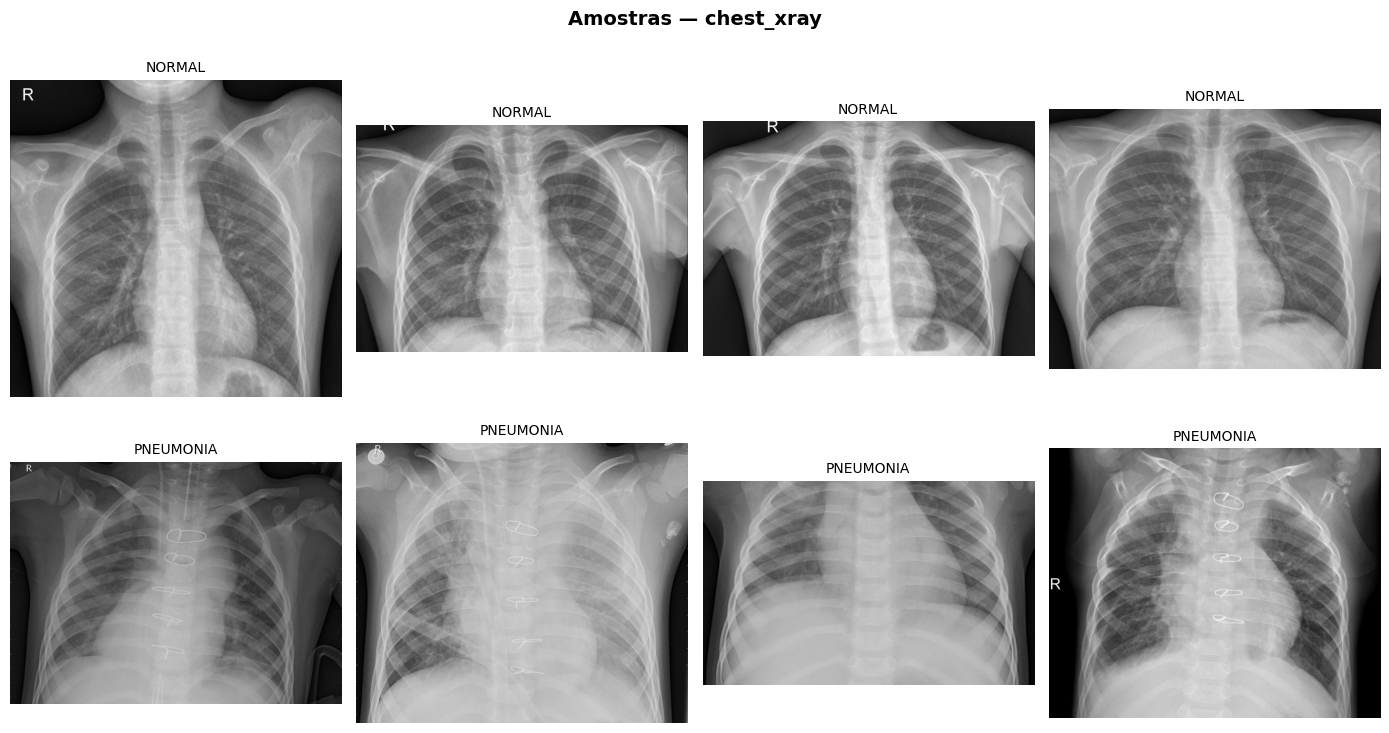

In [8]:
for ds in datasets:
    classes = df[df['dataset'] == ds]['classe'].unique()
    n_cols  = 4
    n_rows  = len(classes)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    if n_rows == 1:
        axes = [axes]

    for row_idx, classe in enumerate(classes):
        amostras = df[
            (df['dataset'] == ds) &
            (df['classe']  == classe) &
            (df['altura'].notna())
        ].sample(min(n_cols, 4), random_state=42)

        for col_idx, (_, sample) in enumerate(amostras.iterrows()):
            img = cv2.imread(sample['caminho'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row_idx][col_idx].imshow(img)
            axes[row_idx][col_idx].set_title(classe, fontsize=10)
            axes[row_idx][col_idx].axis('off')

        for col_idx in range(len(amostras), n_cols):
            axes[row_idx][col_idx].axis('off')

    plt.suptitle(f'Amostras — {ds}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'graphs/amostras_{ds.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')

## Imagens Corrompidas

In [9]:
corrompidas = df[df['altura'].isna()]
print(f"Total de imagens corrompidas: {len(corrompidas)}")

if len(corrompidas) > 0:
    print(corrompidas[['dataset', 'classe', 'imagem', 'caminho']].to_string(index=False))
    df = df[df['altura'].notna()].reset_index(drop=True)
    print(f"Removidas. Restam {len(df)} imagens.")
else:
    print("Nenhuma imagem corrompida.")

Total de imagens corrompidas: 0
Nenhuma imagem corrompida.


## Pré-processamento — Resize, Normalização

Shape  : (224, 224, 3)
Min/Max: 0.0431 / 0.9686
Dtype  : float32


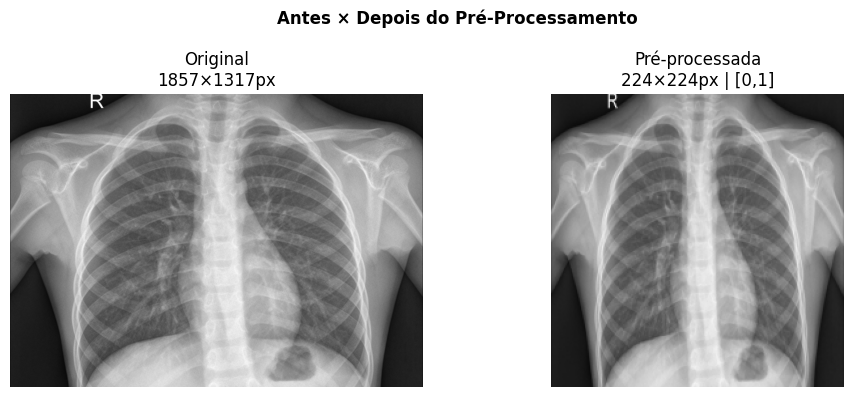

In [10]:
def preprocessar_imagem(caminho, target_size=TARGET_SIZE, normalizar=True):
    """Lê, redimensiona e normaliza uma imagem para float32 em [0, 1]."""
    img = cv2.imread(caminho)
    if img is None:
        raise ValueError(f"Imagem não encontrada: {caminho}")
    
    # BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Redimensionamento
    img = cv2.resize(img, (target_size[1], target_size[0]), interpolation=cv2.INTER_AREA)
    
    # Normalização
    if normalizar:
        img = img.astype(np.float32) / 255.0
    return img


sample_path = df['caminho'].iloc[0]
img_proc    = preprocessar_imagem(sample_path)
img_orig    = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)

print(f"Shape  : {img_proc.shape}")
print(f"Min/Max: {img_proc.min():.4f} / {img_proc.max():.4f}")
print(f"Dtype  : {img_proc.dtype}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_orig)
plt.title(f'Original\n{img_orig.shape[1]}×{img_orig.shape[0]}px')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_proc)
plt.title(f'Pré-processada\n{TARGET_SIZE[1]}×{TARGET_SIZE[0]}px | [0,1]')
plt.axis('off')
plt.suptitle('Antes × Depois do Pré-Processamento', fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/preprocessamento_exemplo.png', dpi=150, bbox_inches='tight')

## Equalization

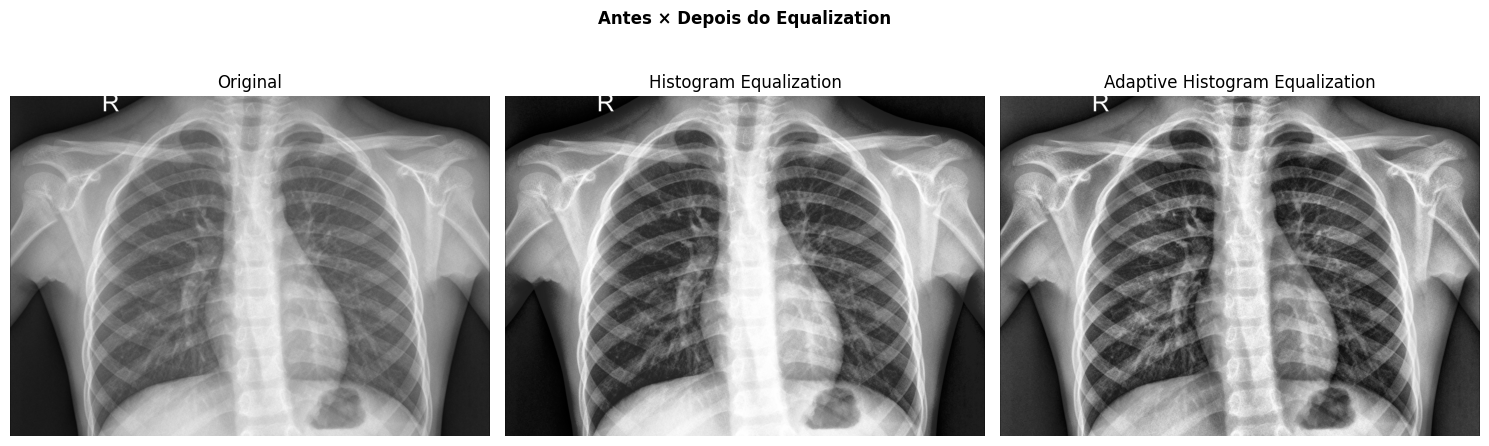

In [ ]:
def histogram_equalization(caminho):
    """Aplica histogram equalization na imagem"""
    img = cv2.imread(caminho)
    if img is None:
        raise ValueError(f"Imagem não encontrada: {caminho}")
    
    # Converte BGR -> grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Histogram Equalization
    img = cv2.equalizeHist(img_gray)
    
    return img

def adaptive_histogram_equalization(caminho):
    """Aplica adaptive histogram equalization na imagem"""
    img = cv2.imread(caminho)
    if img is None:
        raise ValueError(f"Imagem não encontrada: {caminho}")
    
    # Converte BGR -> grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Adaptive Histogram Equalization
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img_gray)
    
    return img


sample_path = df['caminho'].iloc[0]
img_hist = histogram_equalization(sample_path)
img_adaphist = adaptive_histogram_equalization(sample_path)
img_orig = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_orig)
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(img_hist, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(img_adaphist, cmap='gray')
plt.title('Adaptive Histogram Equalization')
plt.axis('off')

plt.suptitle('Antes × Depois do Equalization', fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/equalization_exemplo.png', dpi=150, bbox_inches='tight')

## Data Augmentation

- Data Augmentation configurado.
   Rotação: ±15° | Shift: ±5% | Zoom: ±10% | Flip H | Brilho: 85–115%


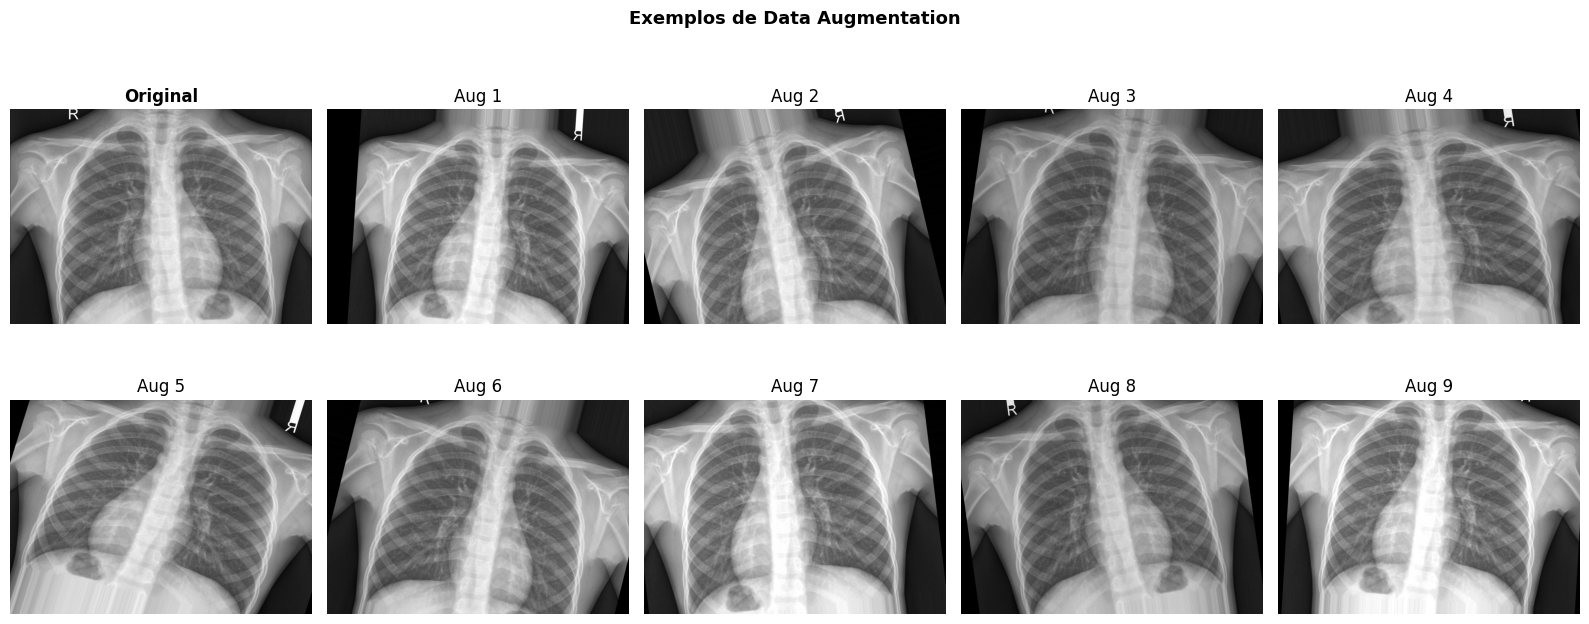

In [12]:
train_datagen    = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 15,
    width_shift_range  = 0.05,
    height_shift_range = 0.05,
    zoom_range         = 0.1,
    horizontal_flip    = True,
    brightness_range   = [0.85, 1.15],
    fill_mode          = 'nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("- Data Augmentation configurado.")
print("   Rotação: ±15° | Shift: ±5% | Zoom: ±10% | Flip H | Brilho: 85–115%")

# Visualização — usa imagem uint8 original (0-255), o rescale fica por conta do gerador
img_orig_uint8  = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
sample_expanded = np.expand_dims(img_orig_uint8, axis=0).astype(np.uint8)

aug_gen = ImageDataGenerator(
    rescale            = 1./255,   # ← obrigatório aqui para a visualização ficar correta
    rotation_range     = 15,
    width_shift_range  = 0.05,
    height_shift_range = 0.05,
    zoom_range         = 0.1,
    horizontal_flip    = True,
    brightness_range   = [0.85, 1.15],
    fill_mode          = 'nearest'
)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes[0][0].imshow(img_orig_uint8)
axes[0][0].set_title('Original', fontweight='bold')
axes[0][0].axis('off')

aug_iter = aug_gen.flow(sample_expanded, batch_size=1)
for idx in range(1, 10):
    aug_img  = next(aug_iter)[0]
    row, col = divmod(idx, 5)
    axes[row][col].imshow(np.clip(aug_img, 0, 1))
    axes[row][col].set_title(f'Aug {idx}')
    axes[row][col].axis('off')

plt.suptitle('Exemplos de Data Augmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/data_augmentation_exemplos.png', dpi=150, bbox_inches='tight')

## Divisão Treino / Validação / Teste

In [13]:
X = df['caminho'].values
y = df['classe'].values

# 70% treino | 15% validação | 15% teste — estratificado por classe
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("=" * 42)
print(f"{'DIVISÃO DO DATASET':^42}")
print("=" * 42)
print(f"  Treino    : {len(X_train):>6}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validação : {len(X_val):>6}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Teste     : {len(X_test):>6}  ({len(X_test)/len(X)*100:.1f}%)")
print("=" * 42)

for nome, y_split in [("Treino", y_train), ("Validação", y_val), ("Teste", y_test)]:
    c     = Counter(y_split)
    total = len(y_split)
    pcts  = {k: f"{v} ({v/total*100:.1f}%)" for k, v in c.items()}

            DIVISÃO DO DATASET            
  Treino    :     21  (70.0%)
  Validação :      4  (13.3%)
  Teste     :      5  (16.7%)


## Salvar Splits em CSV

In [14]:
df_train_out = pd.DataFrame({'caminho': X_train, 'classe': y_train, 'split': 'train'})
df_val_out   = pd.DataFrame({'caminho': X_val,   'classe': y_val,   'split': 'val'})
df_test_out  = pd.DataFrame({'caminho': X_test,  'classe': y_test,  'split': 'test'})

df_splits = pd.concat([df_train_out, df_val_out, df_test_out], ignore_index=True)

save_path = os.path.join(base_path, '..', 'splits_dataset.csv')
df_splits.to_csv(save_path, index=False)

print(f"\n- Splits salvos em: {os.path.abspath(save_path)}")
print(df_splits['split'].value_counts().to_string())


- Splits salvos em: c:\Users\miche\OneDrive\puc\tcc\cnn_pneumonia_xray_eval\notebooks\splits_dataset.csv
split
train    21
test      5
val       4
